# Primate Research

Can books change cultures?

The 1975 publication of the book Animal Liberation by Peter Singer is often credited with sparking an animal rights movement. Did it? Let's look at word usage data to explore this claim? We will focus on primates used in biomedical research.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'animal-word-trends-primate-research.csv'.

# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('animal-word-trends-primate-research.csv')
df.head()

,year,word,frequency
0,1900,baboon,0.500520
1,1900,marmoset,0.098320
2,1900,primate,1.652149
3,1900,rhesus,0.110651
4,1901,baboon,0.505336


In [3]:
def plot_word_trend( animal ):
    trend = df.query('word == @animal')
    plt.figure(figsize=(5, 3))
    plt.plot(trend['year'], trend['frequency'], label=animal)
    plt.ylabel('Frequency per million')
    plt.title(f'Word usage for "{animal}" and year Animal Liberation book published')
    plt.axvline(1975, color='orange', ls='--')

Explore word trends for primates used in research.

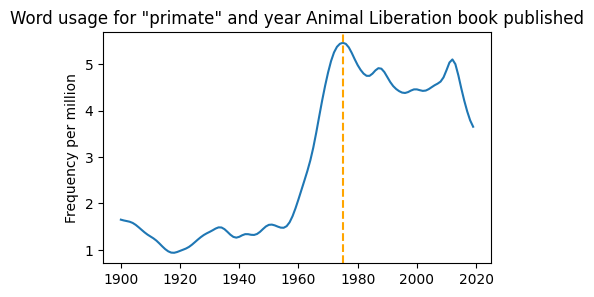

In [4]:
plot_word_trend('primate')
# try primate, marmoset, baboon, rhesus

### How animal research changed

Let's look at another dataset to see what was happening with the research.

In [5]:
counts = pd.read_csv('number-of-research-animals-per-year.csv')
counts.head(2)

,year,primates,dogs,cats,rabbits,guinea_pigs,hamsters
0,1973,42298,195157,66195,447570,408970,454986
1,1974,51253,199204,74259,425585,430439,430766


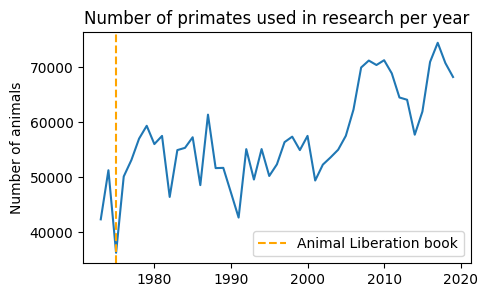

In [6]:
def plot_animal_research( animal ):
	plt.figure(figsize=(5, 3))
	plt.plot(counts['year'], counts[animal])
	plt.axvline(1975, label='Animal Liberation book', color='orange', ls='--')
	plt.ylabel('Number of animals')
	plt.title(f'Number of {animal} used in research per year')
	plt.legend()
	plt.show()

plot_animal_research('primates')

# Project Ideas

- Describe the word usage trends for primates used in animal research in relation to the publication of the book Animal Liberation. 

- Describe trends in the number of primates used in research over time.

- Explore potential explanations for the word usage trends.

- What conclusions can you draw about the claim that the book Animal Liberation sparked an animal rights movement?

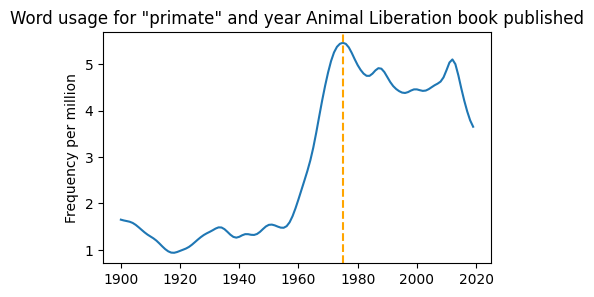

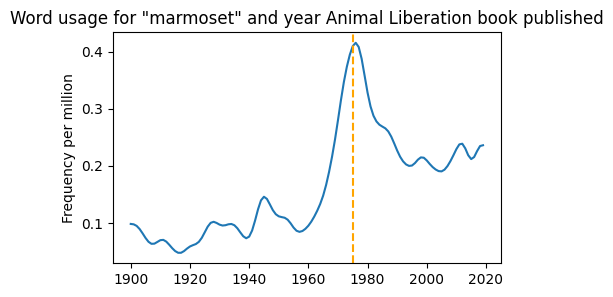

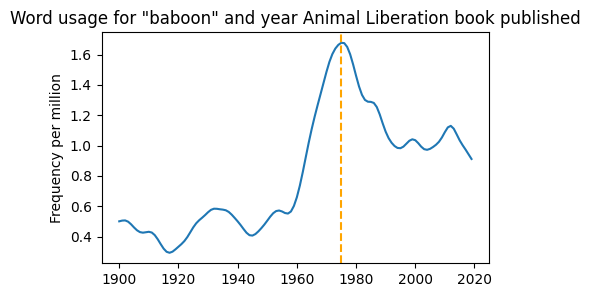

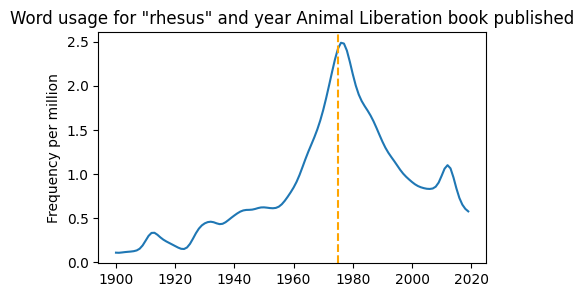

In [7]:
# ── 1. Word trends for all primate research words ─────────────────────────────
primates = ['primate', 'marmoset', 'baboon', 'rhesus']

for animal in primates:
    plot_word_trend(animal)

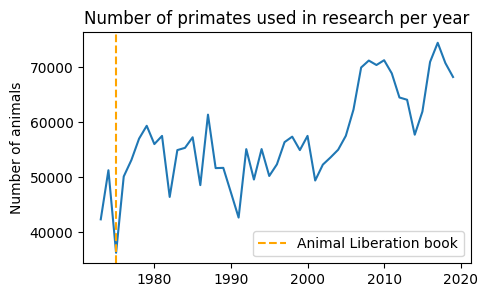

Available research animal columns: ['primates', 'dogs', 'cats', 'rabbits', 'guinea_pigs', 'hamsters']


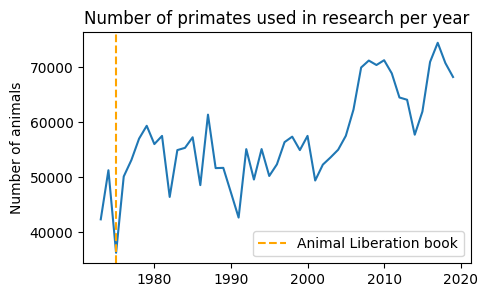

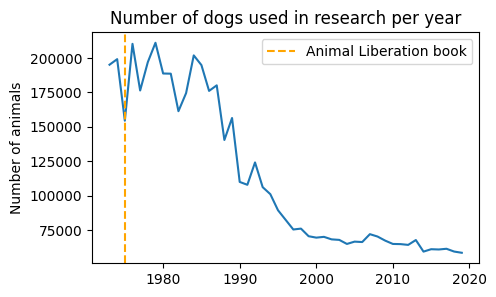

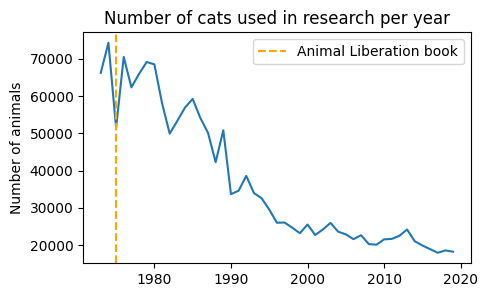

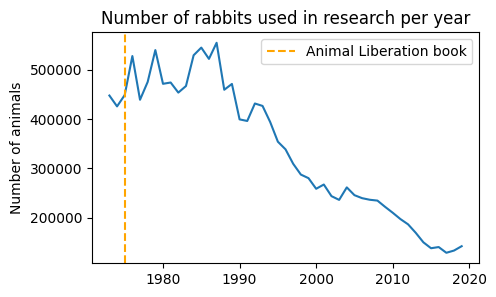

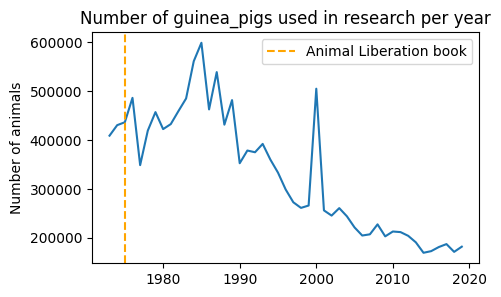

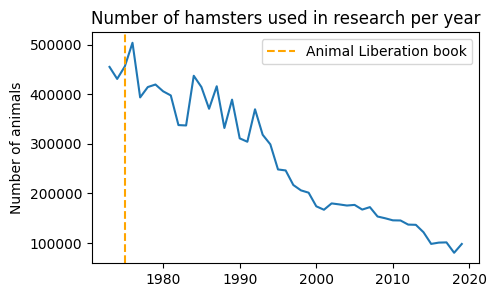

In [8]:
# ── 2. Research animal counts over time ───────────────────────────────────────
plot_animal_research('primates')

# Plot all available animal columns for context
research_animals = [col for col in counts.columns if col != 'year']
print("Available research animal columns:", research_animals)

for animal in research_animals:
    plot_animal_research(animal)

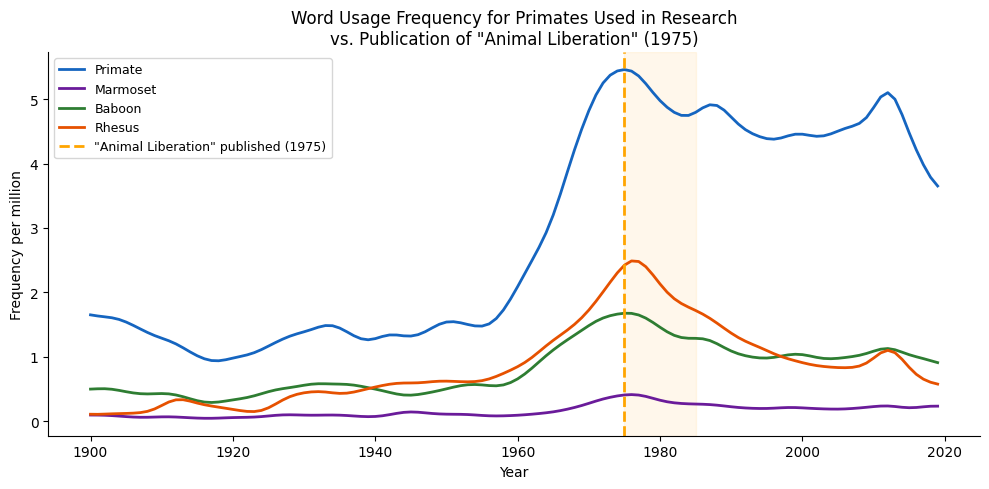

In [9]:
# ── 3. Combined chart: all primate words on one figure ────────────────────────
plt.figure(figsize=(10, 5))

colors = ['#1565C0', '#6A1B9A', '#2E7D32', '#E65100']
for animal, color in zip(primates, colors):
    trend = df.query('word == @animal')
    plt.plot(trend['year'], trend['frequency'],
             label=animal.title(), color=color, linewidth=2)

plt.axvline(1975, color='orange', ls='--', linewidth=2,
            label='"Animal Liberation" published (1975)')
plt.axvspan(1975, 1985, color='orange', alpha=0.08)   # highlight decade after book

plt.ylabel('Frequency per million')
plt.xlabel('Year')
plt.title('Word Usage Frequency for Primates Used in Research\nvs. Publication of "Animal Liberation" (1975)')
plt.legend(fontsize=9)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [10]:
# ── 4. Before vs after 1975: average word frequency comparison ────────────────
print("Average Word Frequency: Before vs After 1975")
print("=" * 50)
print(f"{'Animal':<12} {'Before 1975':>12} {'After 1975':>12} {'% Change':>10}")
print("-" * 50)

for animal in primates:
    trend = df.query('word == @animal')
    before = trend[trend['year'] < 1975]['frequency'].mean()
    after  = trend[trend['year'] >= 1975]['frequency'].mean()
    change = (after - before) / before * 100
    print(f"{animal:<12} {before:>12.3f} {after:>12.3f} {change:>+10.1f}%")

Average Word Frequency: Before vs After 1975
Animal        Before 1975   After 1975   % Change
--------------------------------------------------
primate             1.850        4.663     +152.0%
marmoset            0.113        0.247     +118.3%
baboon              0.623        1.149      +84.5%
rhesus              0.610        1.293     +112.0%


In [11]:
# ── 5. Research counts: before vs after 1975 ─────────────────────────────────
print("\nAverage Number of Primates in Research: Before vs After 1975")
print("=" * 55)

before_avg = counts[counts['year'] < 1975]['primates'].mean()
after_avg  = counts[counts['year'] >= 1975]['primates'].mean()
change     = (after_avg - before_avg) / before_avg * 100

print(f"Before 1975 avg: {before_avg:,.0f}")
print(f"After  1975 avg: {after_avg:,.0f}")
print(f"Change:          {change:+.1f}%")


Average Number of Primates in Research: Before vs After 1975
Before 1975 avg: 46,776
After  1975 avg: 57,549
Change:          +23.0%
